In [28]:
from google.colab import files
uploaded = files.upload()

Saving Airplane_Crashes_and_Fatalities_Since_1908.csv to Airplane_Crashes_and_Fatalities_Since_1908 (3).csv


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df= pd.read_csv("Airplane_Crashes_and_Fatalities_Since_1908.csv")
df.head()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [30]:
df.shape

(5268, 13)

In [31]:
df.tail(75)

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,05/20/2009,06:30,"Near Madiun, Indonesia",Military - Indonesian Air Force,NaN,Jakarta - Maduin,Lockheed C-130 Hercules,A-1325,1982,112.0,98.0,2.0,"While on approach, the military transport cras..."
5264,05/26/2009,NaN,"Near Isiro, DemocratiRepubliCongo",Service Air,NaN,Goma - Isiro,Antonov An-26,9Q-CSA,5005,4.0,4.0,NaN,The cargo plane crashed while on approach to I...
5265,06/01/2009,00:15,"AtlantiOcean, 570 miles northeast of Natal, Br...",Air France,447,Rio de Janeiro - Paris,Airbus A330-203,F-GZCP,660,228.0,228.0,0.0,The Airbus went missing over the AtlantiOcean ...
5266,06/07/2009,08:30,"Near Port Hope Simpson, Newfoundland, Canada",Strait Air,NaN,Lourdes de BlanSablon - Port Hope Simpson,Britten-Norman BN-2A-27 Islander,C-FJJR,424,1.0,1.0,0.0,The air ambulance crashed into hills while att...


In [32]:
df.isnull()

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,False,False,False,False,True,False,False,True,False,False,False,False,False
1,False,False,False,False,True,False,False,True,True,False,False,False,False
2,False,True,False,False,False,True,False,True,True,False,False,False,False
3,False,False,False,False,True,True,False,True,True,False,False,False,False
4,False,False,False,False,True,True,False,True,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5263,False,False,False,False,True,False,False,False,False,False,False,False,False
5264,False,True,False,False,True,False,False,False,False,False,False,True,False
5265,False,False,False,False,False,False,False,False,False,False,False,False,False
5266,False,False,False,False,True,False,False,False,False,False,False,False,False


In [33]:
df.isnull().sum()

,0
Date,0
Time,2219
Location,20
Operator,18
Flight #,4199
Route,1707
Type,27
Registration,335
cn/In,1228
Aboard,22


In [34]:
df['Time']= df['Time'].fillna('Not Known')

In [35]:
df['Location']= df['Location'].fillna('Not Known')  #Locations cannot be predicted hence we label them with not known
df['Operator']= df['Operator'].fillna('Not Known')  # The number of missing values is small hence to avoid adding operator fill with not known
df['Route']= df['Route'].fillna('Not Known')        #Route has a large number of missing values hence to avoid adding inaccurate values , we fill with not known
df['Registration']= df['Registration'].fillna('Not Known')  #The registration of an aircraft cannot be guessed or predicted hence it is filled with not known (they are unique)
df['Summary']= df['Summary'].fillna('Not Known')  # we cannot perform either mean or median on summary hence fill with not known

In [36]:
df['Aboard']=df['Aboard'].fillna(df['Aboard'].median())  #we used median because of precence of outliers in the data in which would raise the mean giving not so approporate values.
df['Fatalities']=df['Fatalities'].fillna(df['Fatalities'].median())  #we also used median because of precence of outliers in the data in which would raise the mean giving not so approporate values.
df['Ground']=df['Ground'].fillna(0)  #adding some ground casualties may interfere with the data since if they are missing it may mean they did not occur

In [37]:
df.isnull().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Flight #,4199
Route,0
Type,27
Registration,0
cn/In,1228
Aboard,0


In [38]:
df['Type']= df['Type'].fillna('Not Known')
df['cn/In']= df['cn/In'].fillna('Not Known')
df['Flight #']= df['Flight #'].fillna('Not Known')

In [39]:
df.isnull().sum()

,0
Date,0
Time,0
Location,0
Operator,0
Flight #,0
Route,0
Type,0
Registration,0
cn/In,0
Aboard,0


In [40]:
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()
fatality_locations.head()

,Date,Location,Aboard,Fatalities
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0
3,09/09/1913,Over the North Sea,20.0,14.0
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0


In [41]:
# Question 6:
max_row = fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]

print(f"Date: {max_row['Date']}")
print(f"Fatalities: {max_row['Fatalities']}")
print(f"Location: {max_row['Location']}")

Date: 03/27/1977
Fatalities: 583.0
Location: Tenerife, Canary Islands


In [42]:
# Question 7:
zero_fatality_crashes = fatality_locations[fatality_locations['Fatalities'] == 0]

print(f"Crashes with zero fatalities: {len(zero_fatality_crashes)}")
fatality_locations[['Aboard', 'Fatalities']].describe()

Crashes with zero fatalities: 58


,Aboard,Fatalities
count,5268.000000,5268.000000
mean,27.493736,20.043090
std,42.996900,33.166309
min,0.000000,0.000000
25%,5.000000,3.000000
50%,13.000000,9.000000
75%,30.000000,23.000000
max,644.000000,583.000000


In [43]:
fatality_locations[['Region', 'State_Country']] = fatality_locations['Location'].str.rsplit(',', n=1, expand=True)

fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State_Country'] = fatality_locations['State_Country'].str.strip()

fatality_locations.head()

,Date,Location,Aboard,Fatalities,Region,State_Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,"Victoria, British Columbia",Canada
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany


In [44]:
top_100 = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)
top_100

,Date,Location,Aboard,Fatalities,Region,State_Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,"Mt. Osutaka, near Ueno Village",Japan
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3970,10/02/1990,"Guangzhou, China",226.0,128.0,Guangzhou,China
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,"Elburz Mtns., near Laskarak, Markazi",Iran


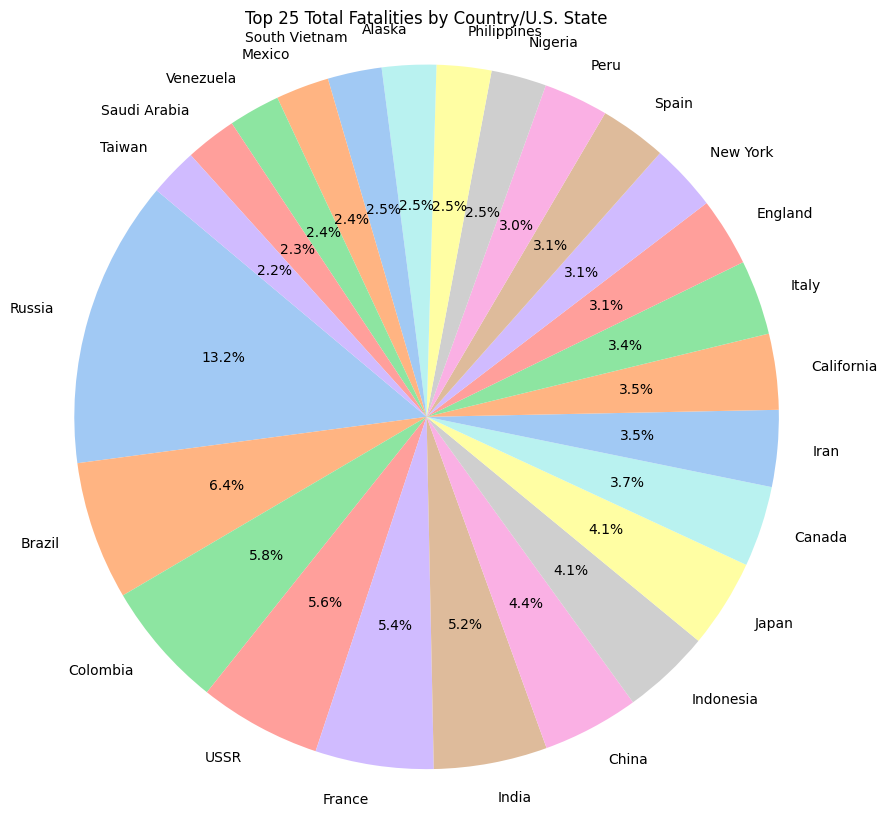

In [45]:
plt.figure(figsize=(10, 10))

top_25 = fatality_locations.groupby('State_Country')['Fatalities'].sum().nlargest(25)

colors = sns.color_palette('pastel')[0:25]
plt.pie(top_25, labels=top_25.index, autopct='%1.1f%%', colors=colors, startangle=140)
plt.title('Top 25 Total Fatalities by Country/U.S. State')
plt.axis('equal')
plt.show()